In [ ]:
from dataclasses import dataclass
import numpy as np
import nn
from matplotlib import pyplot as plt
import logging

logging.basicConfig(level=logging.WARN, format="%(message)s")
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [508]:
n = 10_000
theta = 6 * np.pi * np.random.random(n).reshape((n, 1))
r = 6 * np.pi * np.random.random(n).reshape((n, 1))
y = np.abs((r - theta) % (2 * np.pi)).flatten() < np.pi
X = r * np.concatenate([np.cos(theta), np.sin(theta)], axis=1)

In [20]:
X

array([[-2.25865915, 13.72880708],
       [15.13639184,  4.03296744],
       [ 0.89216482, -0.640605  ],
       ...,
       [-9.75249826, -7.81587069],
       [ 4.95001613,  4.68306067],
       [ 3.41447384, 16.28801417]], shape=(10000, 2))

In [509]:
l1 = nn.Linear(1 / (X.std() * np.sqrt(2)) * np.random.normal(size=(10, 2)))
act1 = nn.Max0()
l2 = nn.Linear(1 / np.sqrt(10) * np.random.normal(size=(10, 10)))
act2 = nn.Max0()
l3 = nn.Linear(1 / np.sqrt(10) * np.random.normal(size=(1, 10)))
act3 = nn.MapTo01()   

layers = [l1, act1, l2, act2, l3, act3]
neural_network = nn.NN(layers)

In [437]:
X[10,:], y[10]

(array([ 0.69733823, -3.82797055]), np.False_)

In [519]:
logger.setLevel(logging.DEBUG)

random_sample = np.random.choice(len(X), size=10, replace=False)

for training_iteration in range(100):
    for i in random_sample:
        loss_function = nn.SquaredErrorLoss()
        output = neural_network.run(X[i,:])
        logger.debug(f"output: {output}")
        loss = loss_function.get_loss(output, y[i])
        logger.debug(f"loss: {loss}")
        output_gradient = loss_function.output_gradient(output, y[i])
        logger.debug(f"output_gradient: {output_gradient}")
        neural_network.update(output_gradient, learning_rate=0.01, regularization=0.00001)

    if training_iteration % 100 == 0:
        logger.info(f"--------------------training iteration: {training_iteration}---------------------")
        neural_network.debug_print()

output: [0.0056979]
loss: [0.98863666]
output_gradient: [-1.9886042]
output: [0.97963564]
loss: [0.00041471]
output_gradient: [-0.04072872]
output: [0.62268634]


loss: [0.38773828]
output_gradient: [1.24537268]
output: [0.00088075]
loss: [0.99823928]
output_gradient: [-1.9982385]
output: [0.80072267]
loss: [0.03971146]
output_gradient: [-0.39855467]
output: [0.4400245]
loss: [0.19362156]
output_gradient: [0.88004901]
output: [0.75435558]
loss: [0.06034118]
output_gradient: [-0.49128885]
output: [0.56843064]
loss: [0.32311339]
output_gradient: [1.13686127]
output: [0.98370574]
loss: [0.96767699]
output_gradient: [1.96741149]
output: [0.99943698]
loss: [3.16990279e-07]
output_gradient: [-0.00112604]
--------------------training iteration: 0---------------------
output: [0.00268131]
loss: [0.99464457]
output_gradient: [-1.99463738]
output: [0.97012354]
loss: [0.0008926]
output_gradient: [-0.05975292]
output: [0.61494776]
loss: [0.37816074]
output_gradient: [1.22989551]
output: [0.00039801]
loss: [0.99920413]
output_gradient: [-1.99920397]
output: [0.79263186]
loss: [0.04300155]
output_gradient: [-0.41473628]
output: [0.42036773]
loss: [0.17670903]

Layer 0: Linear (2 -> 10)
  weights shape: (10, 2)
  weights:
[[-0.9023  0.4453]
 [-0.2923 -0.6581]
 [-0.9967 -0.7522]
 [ 0.0986  0.66  ]
 [-1.9173 -0.0116]
 [-0.5227  0.4336]
 [-1.0815 -0.9256]
 [ 0.0333 -1.5826]
 [-0.7444  0.2164]
 [ 0.712  -0.9424]]
  weight stats: min=-1.9173, max=0.7120, mean=-0.4365

Layer 1: Max0

Layer 2: Linear (10 -> 10)
  weights shape: (10, 10)
  weights:
[[ 0.1339  0.5286  0.1893 -0.3683  0.4152 -0.235   0.7147  0.2306  0.2092
  -0.0939]
 [-0.0394  0.1171 -0.2367  0.6906 -0.3515 -0.1137 -0.1814  0.3701 -0.2212
  -0.0423]
 [ 0.5732  0.0608 -0.2581  0.2301  0.3204  0.0892  0.0185  0.3148  0.6139
  -0.39  ]
 [ 0.1393  0.0253  0.395   0.3205  0.0172  0.0235 -0.3303  0.712   0.4557
   0.409 ]
 [ 0.6189  0.4419 -0.0273 -0.3245  0.0363 -0.0766  0.0905  0.0372 -0.0504
   0.022 ]
 [-0.2298  0.0502  0.552   0.3856  0.3873  0.0436  0.3016  0.7437  0.2126
  -0.2248]
 [-0.5087 -0.0271  0.1955  0.6696 -0.0541 -0.2311 -0.2977 -0.1809  0.2082
  -0.1142]
 [-0.3028  0.4292 

output_gradient: [-0.01974105]
output: [0.00058637]
loss: [0.9988276]
output_gradient: [-1.99882726]
output: [0.90787556]
loss: [0.00848691]
output_gradient: [-0.18424888]
output: [0.58164108]
loss: [0.33830634]
output_gradient: [1.16328216]
output: [0.00010292]
loss: [0.99979416]
output_gradient: [-1.99979415]
output: [0.76497941]
loss: [0.05523468]
output_gradient: [-0.47004118]
output: [0.3625553]
loss: [0.13144635]
output_gradient: [0.7251106]
output: [0.71506602]
loss: [0.08118738]
output_gradient: [-0.56986797]
output: [0.05855055]
loss: [0.00342817]
output_gradient: [0.1171011]
output: [0.96185211]
loss: [0.92515949]
output_gradient: [1.92370423]
output: [0.98855091]
loss: [0.00013108]
output_gradient: [-0.02289817]
output: [0.00050395]
loss: [0.99899236]
output_gradient: [-1.9989921]
output: [0.89768517]
loss: [0.01046832]
output_gradient: [-0.20462965]
output: [0.57749389]
loss: [0.3334992]
output_gradient: [1.15498778]
output: [9.07383693e-05]
loss: [0.99981853]
output_gradie

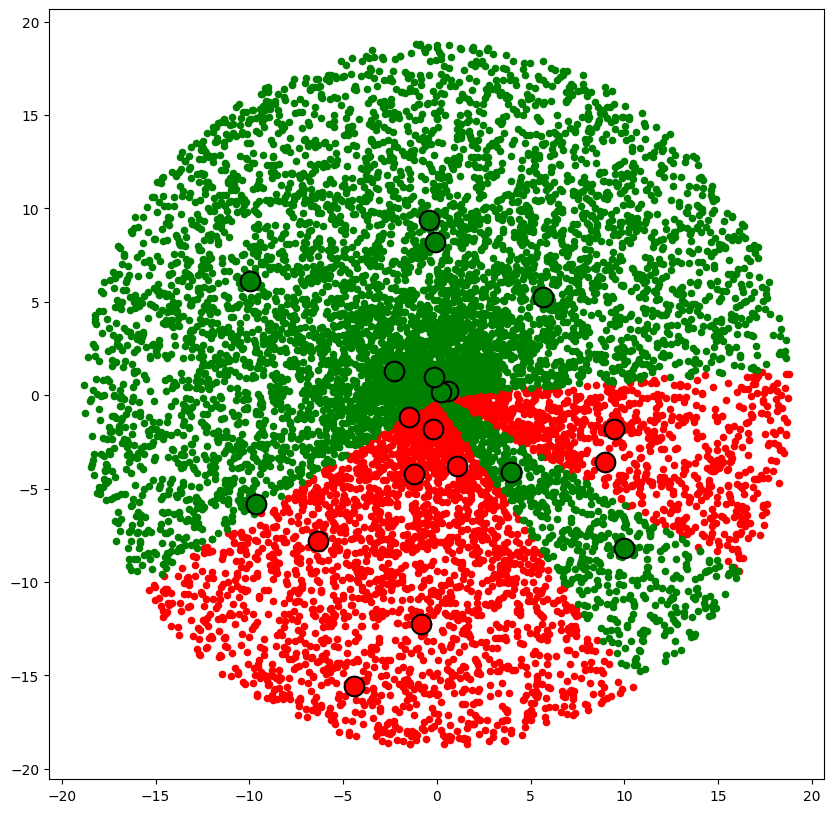

In [511]:
all_points=X
all_predictions = np.array([neural_network.run(x) for x in all_points]).flatten() > 0.5

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~all_predictions, 0], X[~all_predictions, 1], color="r", s=20)
plt.scatter(X[all_predictions, 0], X[all_predictions, 1], color="g", s=20)


sample_points=np.array([X[i,:] for i in random_sample])
sample_predictions = np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5
plt.scatter(sample_points[~sample_predictions, 0], sample_points[~sample_predictions, 1], 
            color="r", s=200, edgecolors="black", linewidths=1.5)
plt.scatter(sample_points[sample_predictions, 0], sample_points[sample_predictions, 1], 
            color="g", s=200, edgecolors="black", linewidths=1.5)


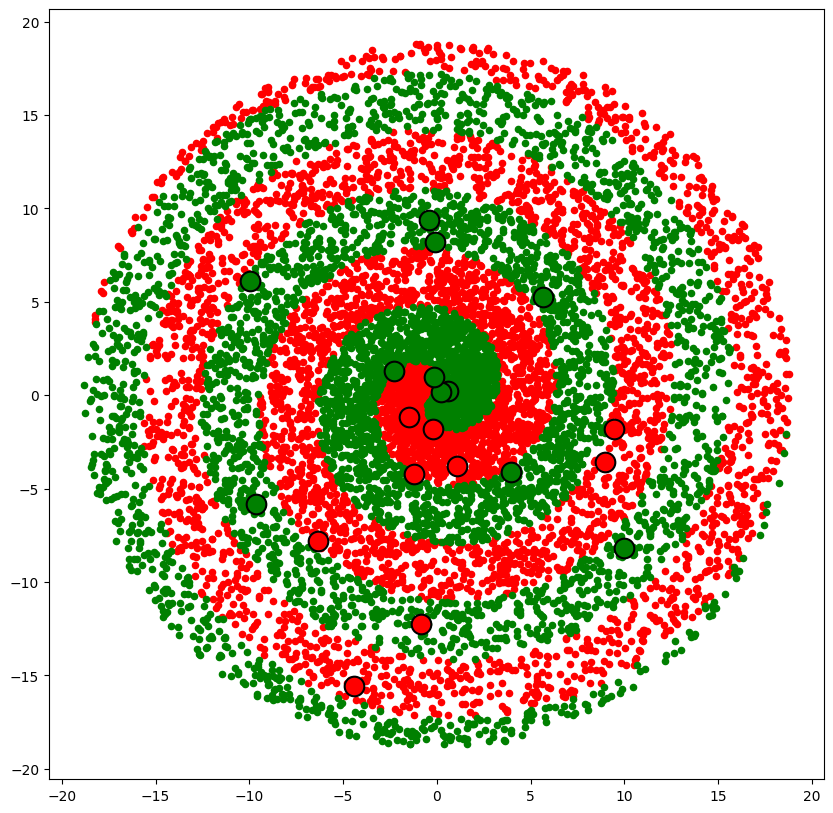

In [512]:
sample_points=np.array([X[i,:] for i in random_sample])
sample_predictions = np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~y, 0], X[~y, 1], color="r", s=20)
plt.scatter(X[y, 0], X[y, 1], color="g", s=20)

plt.scatter(sample_points[~sample_predictions, 0], sample_points[~sample_predictions, 1], 
            color="r", s=200, edgecolors="black", linewidths=1.5)
plt.scatter(sample_points[sample_predictions, 0], sample_points[sample_predictions, 1], 
            color="g", s=200, edgecolors="black", linewidths=1.5)



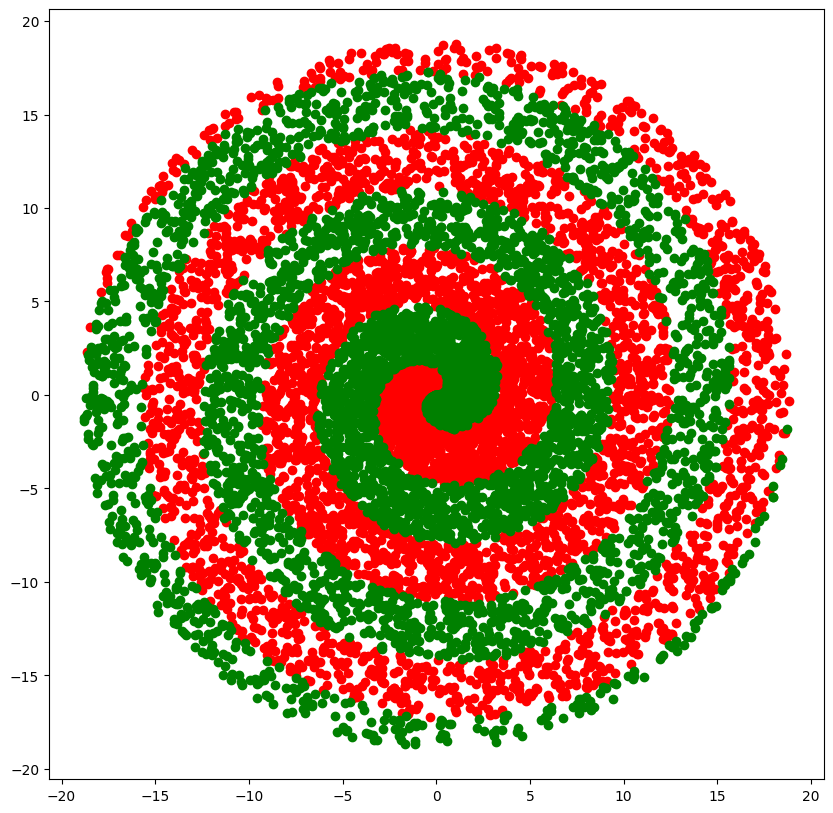

In [93]:
plt.rcParams["figure.figsize"] = (10, 10)
plt.scatter(X[~y, 0], X[~y, 1], color="r")
plt.scatter(X[y, 0], X[y, 1], color="g")

In [4]:
np.arange(6).reshape((3,2))

array([[0, 1],
       [2, 3],
       [4, 5]])

In [6]:
np.arange(1,4).reshape((1,3)) * (10 * np.arange(1,3)).reshape((2,1))

array([[10, 20, 30],
       [20, 40, 60]])